In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Descargar data
Puedes usar el código si configuras tu entorno
En cualquier caso puedes descargar la data desde [Data Give me some credit](https://www.kaggle.com/competitions/give-me-some-credit/data)

In [ ]:
#subir directamente
from google.colab import drive
drive.mount('/content/drive')
path_train= "/content/drive/MyDrive/data/train.csv"
path_test = "/content/drive/MyDrive/data/test.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#en caso hacerlo en local
path_train = "data/train.csv"
path_test = "data/test.csv"

In [3]:
df_train= pd.read_csv(path_train)
df_test = pd.read_csv(path_test)

C:\Users\Diego Roman\AppData\Local\Temp\ipykernel_11756\352102316.py:1: DtypeWarning: Columns (0: Id, 1: SeriousDlqin2yrs, 2: RevolvingUtilizationOfUnsecuredLines, 3: age, 4: NumberOfTime30-59DaysPastDueNotWorse, 5: DebtRatio, 6: MonthlyIncome, 7: NumberOfOpenCreditLinesAndLoans, 8: NumberOfTimes90DaysLate, 9: NumberRealEstateLoansOrLines, 10: NumberOfTime60-89DaysPastDueNotWorse, 11: NumberOfDependents) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train= pd.read_csv(path_train)


# Exploración de los datos
En esta parte primero notaremos como se comportan los datos, teniendo en cuenta los outliers, nulos, porcentaje, para luego hacer el tratamiento de los datos

## Data Dictionary - English


|Variable Name|Description|Type|
|--------------|-----------|------|
|**SeriousDlqin2yrs(target)**|**Person experienced 90 days past due delinquency or worse** |**Y/N**|
|RevolvingUtilizationOfUnsecuredLines|Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits|percentage|
|age|Age of borrower in years|integer|
|NumberOfTime30-59DaysPastDueNotWorse|Number of times borrower has been 30-59 days past due but no worse in the last 2 years|integer|
|DebtRatio|"Monthly debt payments alimony,living costs divided by monthy gross income"|percentage|
|MonthlyIncome|Monthly income,real NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)|integer|
|NumberOfTimes90DaysLate|Number of times borrower has been 90 days or more past due|integer|
|NumberRealEstateLoansOrLines|Number of mortgage and real estate loans including home equity lines of credit|integer|
|NumberOfTime60-89DaysPastDueNotWorse|Number of times borrower has been 60-89 days past due but no worse in the last 2 years|integer|
|NumberOfDependents|"Number of dependents in family excluding themselves (spouse, children etc.)"|integer|

### Diccionario de Datos - Español

|Variable Name|Descripción|Tipo|
|--------------|-----------|------|
|SeriousDlqin2yrs|Persona que ha experimentado mora de 90 días o peor|Y/N|
|RevolvingUtilizationOfUnsecuredLines|Saldo total en tarjetas de crédito y líneas de crédito personales, excluyendo bienes raíces y deudas a plazos como préstamos de automóviles, dividido por la suma de los límites de crédito|porcentaje|
|age|Edad del prestatario en años|entero|
|NumberOfTime30-59DaysPastDueNotWorse|Número de veces que el prestatario ha tenido mora de 30-59 días pero no peor en los últimos 2 años|entero|
|DebtRatio|Pagos mensuales de deuda, pensión alimenticia y costos de vida divididos por el ingreso bruto mensual|porcentaje|
|MonthlyIncome|Ingreso mensual|real|
|NumberOfOpenCreditLinesAndLoans|Número de préstamos abiertos (a plazos como préstamo de automóvil o hipoteca) y líneas de crédito (por ejemplo, tarjetas de crédito)|entero|
|NumberOfTimes90DaysLate|Número de veces que el prestatario ha tenido mora de 90 días o más|entero|
|NumberRealEstateLoansOrLines|Número de préstamos hipotecarios y de bienes raíces, incluidas las líneas de crédito con garantía hipotecaria|entero|
|NumberOfTime60-89DaysPastDueNotWorse|Número de veces que el prestatario ha tenido mora de 60-89 días pero no peor en los últimos 2 años|entero|
|NumberOfDependents|Número de dependientes en la familia, excluyéndose a sí mismo (cónyuge, hijos, etc.)|entero|





In [4]:
df_train.head(10)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
5,6,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
6,7,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
7,8,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
8,10,0,0.644226,30,0,0.309476,2500.0,5,0,0,0,0.0
9,11,0,0.018798,51,0,0.531529,6501.0,7,0,2,0,2.0


In [5]:
df_test.head(10)

,Id,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,9,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0
2,17,0.166284,53,0,0.188274,8800.0,7,0,0,0,0.0
3,18,0.221813,43,0,0.527888,3280.0,7,0,1,0,2.0
4,24,0.046560,58,0,0.241622,2416.0,9,0,1,0,0.0
5,26,0.052436,58,0,0.097672,8333.0,22,0,1,0,0.0
6,31,1.000000,24,0,0.472703,750.0,1,0,0,0,0.0
7,34,0.693330,42,2,0.257732,2230.0,7,0,0,0,0.0
8,35,0.000000,64,0,0.073539,11000.0,9,0,1,0,0.0
9,37,1.000000,75,1,0.134078,3400.0,1,0,1,0,1.0


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  int64  
 1   SeriousDlqin2yrs                      104805 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float64
 3   age                                   104805 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  int64  
 5   DebtRatio                             104805 non-null  float64
 6   MonthlyIncome                         84024 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  int64  
 8   NumberOfTimes90DaysLate               104805 non-null  int64  
 9   NumberRealEstateLoansOrLines          104805 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  int64  
 11  

In [7]:
#porcentaje de nulos para la fila MonthlyIncome
porcentaje_nulos_MonthlyIncome = (df_train.isna().sum()/len(df_train))*100
print(porcentaje_nulos_MonthlyIncome)

Id                                       0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.828252
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.622966
dtype: float64


Notamos que existe un 29.82 porciento de valores nulos en MonthlyIncome y un 2.62 de valores nulos en NumberOfDependents

In [8]:
df_train.describe()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,104805.000000,104805.000000,104805.000000,104805.000000,104805.000000,104805.000000,8.402400e+04,104805.000000,104805.000000,104805.000000,104805.000000,102056.000000
mean,75013.710863,0.066314,5.602014,52.351128,0.416077,354.859470,6.684453e+03,8.454854,0.259988,1.019551,0.235571,0.756065
std,43324.043054,0.248831,217.389876,14.765944,4.139291,2169.182855,1.565313e+04,5.127986,4.115594,1.136847,4.101263,1.112162
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37508.000000,0.000000,0.029801,41.000000,0.000000,0.175026,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,74931.000000,0.000000,0.153984,52.000000,0.000000,0.366626,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112620.000000,0.000000,0.559168,63.000000,0.000000,0.867267,8.250000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,149999.000000,1.000000,29110.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,13.000000


Vamos a explorar con gráficos un poco

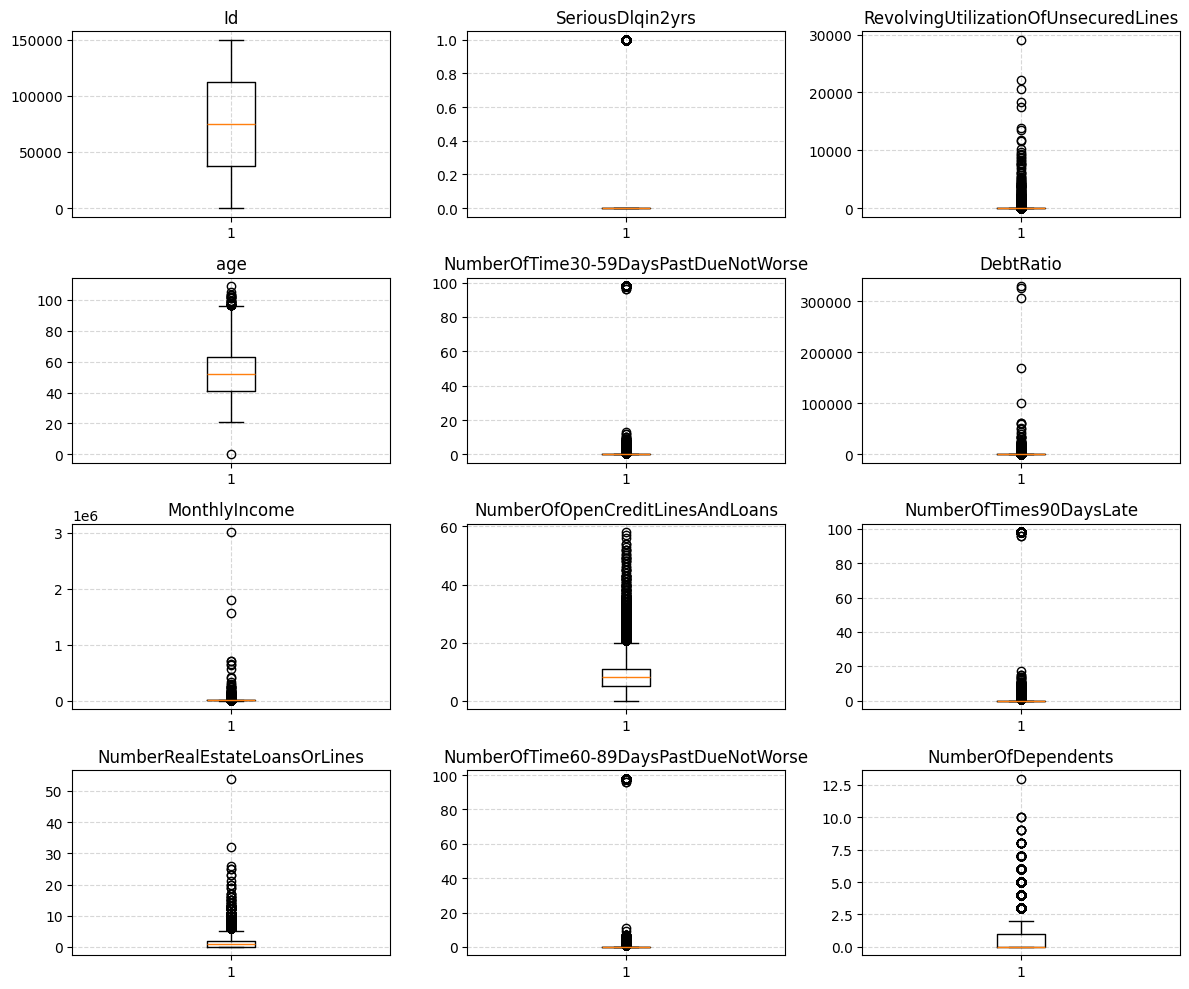

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
ax = ax.flatten()  # Aplana la matriz 4x3 a un array 1D para iterar fácilmente

for i, col in enumerate(df_train.columns):
    if i < len(ax):
        # dropna() evita errores si hay valores faltantes
        ax[i].boxplot(df_train[col].dropna())
        ax[i].set_title(col)
        ax[i].grid(True, linestyle='--', alpha=0.5)

# Oculta los subplots sobrantes si hay menos columnas que ejes
for j in range(len(df_train.columns), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

## Conclusiones a partir del boxplot
1. Age: Se puede notar que las personas que tiene 0 de edad no pueden sacar algún prestamo, así que eliminamos a esas personas.
2. NumberOfTime30-59DaysPastDueNotWorse: Parecen que hay algunos outliers después de 80
3. DebRatio: Algunos valores no tienen que pasan 300000
4. MonthlyIncome: No parecen valores aticos pero si algunos no son pertenecientes, como el aquellos que ganan más de 1e6
5. NumberOfTimes90DaysLate: Existe algunos outliers que están después de 80
6. NumberRealEstateLoansOrLines: Existen valores mayores a 30 que parecen ser outliers
7. NumberOfTime60-89DaysPastDueNotWorse: Los valores que están después de 100 pueden ser outliers


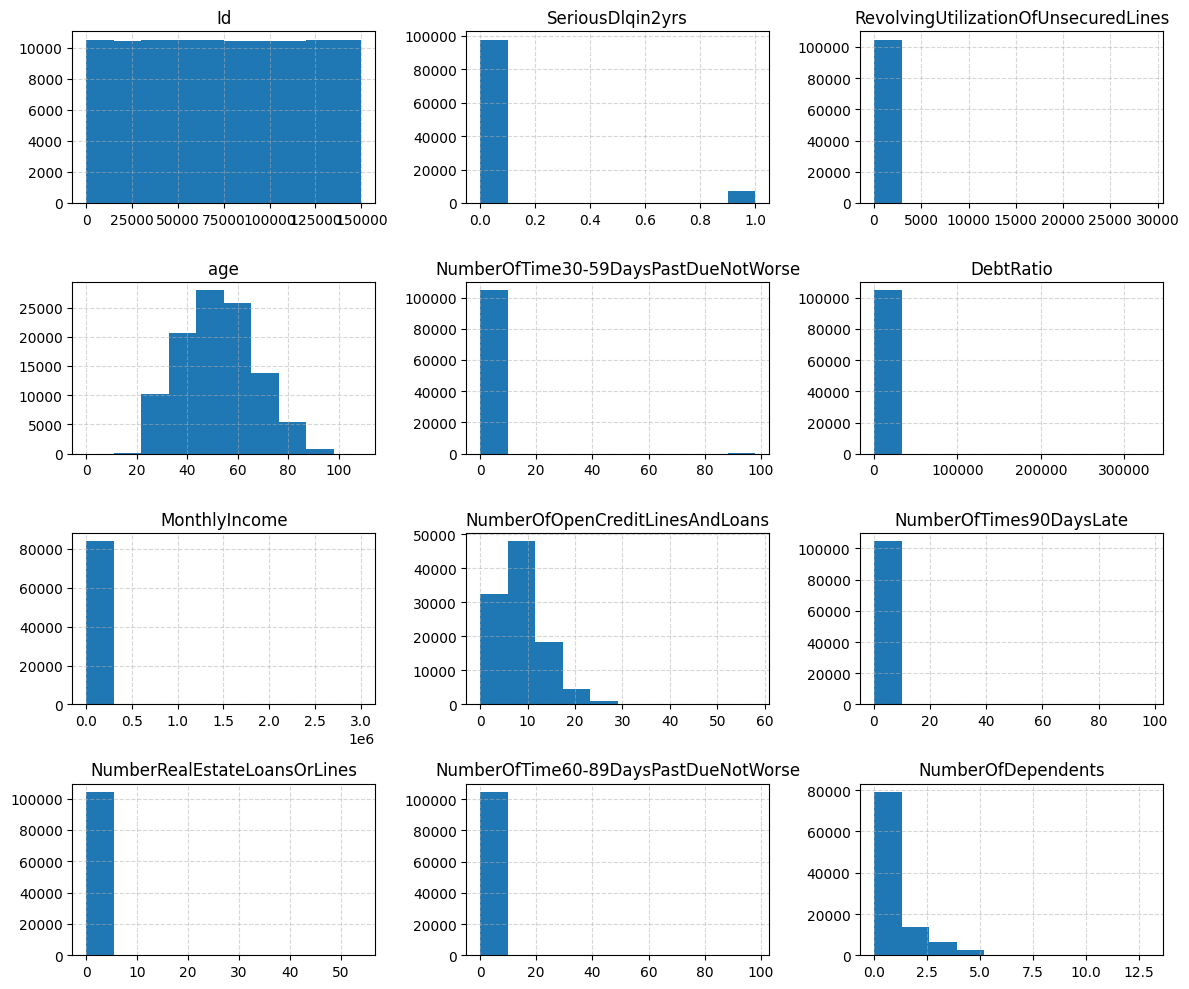

In [10]:
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
ax = ax.flatten()  # Aplana la matriz 4x3 a un array 1D para iterar fácilmente

for i, col in enumerate(df_train.columns):
    if i < len(ax):
        # dropna() evita errores si hay valores faltantes
        ax[i].hist(df_train[col].dropna())
        ax[i].set_title(col)
        ax[i].grid(True, linestyle='--', alpha=0.5)

# Oculta los subplots sobrantes si hay menos columnas que ejes
for j in range(len(df_train.columns), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()